# Разные эксперименты

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from src.structs import Generator, Model, State
from src.utils import grid4, grid8, cluster_graph

np.random.seed(42)

In [2]:
gen = Generator(mean=0.5, std=0.1)
all_results = {}

### Эксперименты с моделью Неймана

In [3]:
n, m = 32, 32
epochs = 25

Зависимость времени значительного распространения слуха (>= 90%), от интересности слуха

In [4]:
Ts = [6, 12, 24, 48]
betas = np.linspace(0.05, 1.0, 20)
all_results["grid4_beta_multiT"] = {
    "betas": betas,
    "Ts": Ts,
    "results": {}
}
for T in Ts:
    res = {
        "success_rate": [],
        "good_mean_time": [],
        "bad_mean_time": []
    }
    for beta in betas:
        good, bad = [], []
        for _ in range(epochs):
            nodes = grid4(gen, n, m)
            center = (n // 2) * m + (m // 2)
            nodes[center].state = State.SPREADER

            model = Model(nodes, beta, T, gen)
            result, wasted_time = model.run_experiment()

            if result:
                good.append(wasted_time)
            else:
                bad.append(wasted_time)
        success_rate = len(good) / epochs
        if not good:
            good = [0]
        if not bad:
            bad = [0]
        res["success_rate"].append(success_rate)
        res["good_mean_time"].append(np.mean(good))
        res["bad_mean_time"].append(np.mean(bad))
    all_results["grid4_beta_multiT"]["results"][T] = res

### Эксперименты с моделью Мура

In [5]:
n, m = 32, 32
epochs = 25

Зависимость времени значительного распространения слуха (>= 90%), от интересности слуха

In [6]:
Ts = [6, 12, 24, 48]
betas = np.linspace(0.05, 1.0, 20)

all_results["grid8_beta_multiT"] = {
    "betas": betas,
    "Ts": Ts,
    "results": {}
}

for T in Ts:
    res = {
        "success_rate": [],
        "good_mean_time": [],
        "bad_mean_time": []
    }

    for beta in betas:
        good, bad = [], []

        for _ in range(epochs):
            nodes = grid8(gen, n, m)
            center = (n // 2) * m + (m // 2)
            nodes[center].state = State.SPREADER

            model = Model(nodes, beta, T, gen)
            result, wasted_time = model.run_experiment()

            if result:
                good.append(wasted_time)
            else:
                bad.append(wasted_time)

        success_rate = len(good) / epochs

        if not good:
            good = [0]
        if not bad:
            bad = [0]

        res["success_rate"].append(success_rate)
        res["good_mean_time"].append(np.mean(good))
        res["bad_mean_time"].append(np.mean(bad))

    all_results["grid8_beta_multiT"]["results"][T] = res

### Эксперименты с моделью Кластерного Графа

#### Плотный граф

In [15]:
n, k = 500, 120
p_in, p_out = 0.9, 0.3
epochs = 25

Зависимость времени значительного распространения слуха (>= 90%), от интересности слуха

In [16]:
Ts = [6, 12, 24, 48]
betas = np.linspace(0.05, 1.0, 20)

all_results["dense_graph_beta_multiT"] = {
    "betas": betas,
    "Ts": Ts,
    "results": {}
}

for T in Ts:
    res = {
        "success_rate": [],
        "good_mean_time": [],
        "bad_mean_time": []
    }

    for beta in betas:
        good, bad = [], []

        for _ in range(epochs):
            gen = Generator(mean=0.5, std=0.1)
            nodes = cluster_graph(gen, n, k, p_in=p_in, p_out=p_out)

            center = n // 2
            nodes[center].state = State.SPREADER

            model = Model(nodes, beta, T, gen)
            result, wasted_time = model.run_experiment()

            if result:
                good.append(wasted_time)
            else:
                bad.append(wasted_time)

        success_rate = len(good) / epochs

        if not good:
            good = [0]
        if not bad:
            bad = [0]

        res["success_rate"].append(success_rate)
        res["good_mean_time"].append(np.mean(good))
        res["bad_mean_time"].append(np.mean(bad))

    all_results["dense_graph_beta_multiT"]["results"][T] = res

#### Разреженный граф

In [13]:
n, k = 500, 120
p_in, p_out = 0.9, 0.05
epochs = 25

In [14]:
Ts = [6, 12, 24, 48]
betas = np.linspace(0.05, 1.0, 20)

all_results["sparse_graph_beta_multiT"] = {
    "betas": betas,
    "Ts": Ts,
    "results": {}
}

for T in Ts:
    res = {
        "success_rate": [],
        "good_mean_time": [],
        "bad_mean_time": []
    }

    for beta in betas:
        good, bad = [], []

        for _ in range(epochs):
            gen = Generator(mean=0.5, std=0.1)
            nodes = cluster_graph(gen, n, k, p_in=p_in, p_out=p_out)

            center = n // 2
            nodes[center].state = State.SPREADER

            model = Model(nodes, beta, T, gen)
            result, wasted_time = model.run_experiment()

            if result:
                good.append(wasted_time)
            else:
                bad.append(wasted_time)

        success_rate = len(good) / epochs

        if not good:
            good = [0]
        if not bad:
            bad = [0]

        res["success_rate"].append(success_rate)
        res["good_mean_time"].append(np.mean(good))
        res["bad_mean_time"].append(np.mean(bad))

    all_results["sparse_graph_beta_multiT"]["results"][T] = res

## Построение графиков для анализа результатов

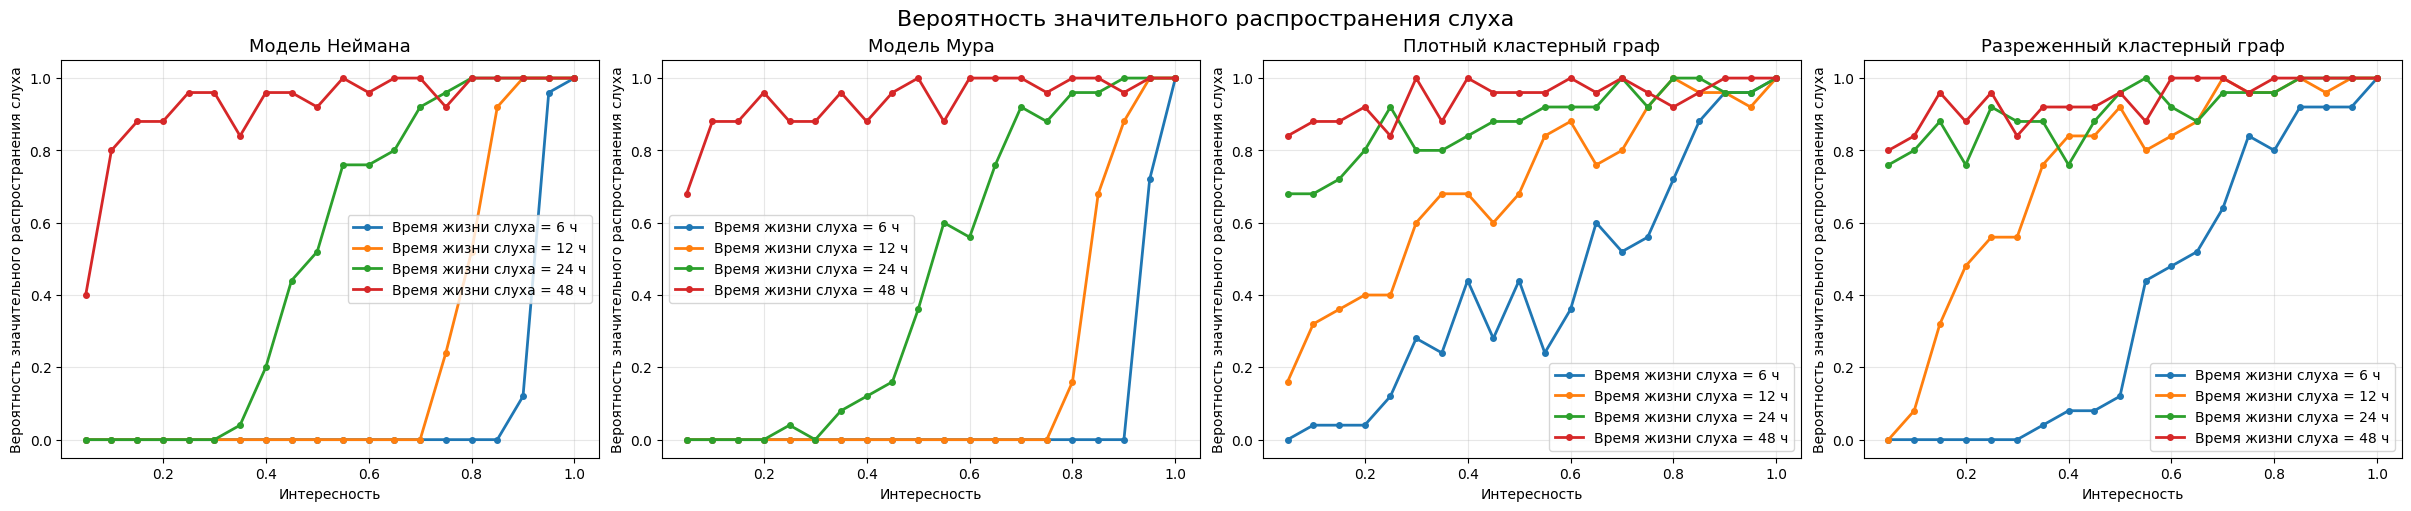

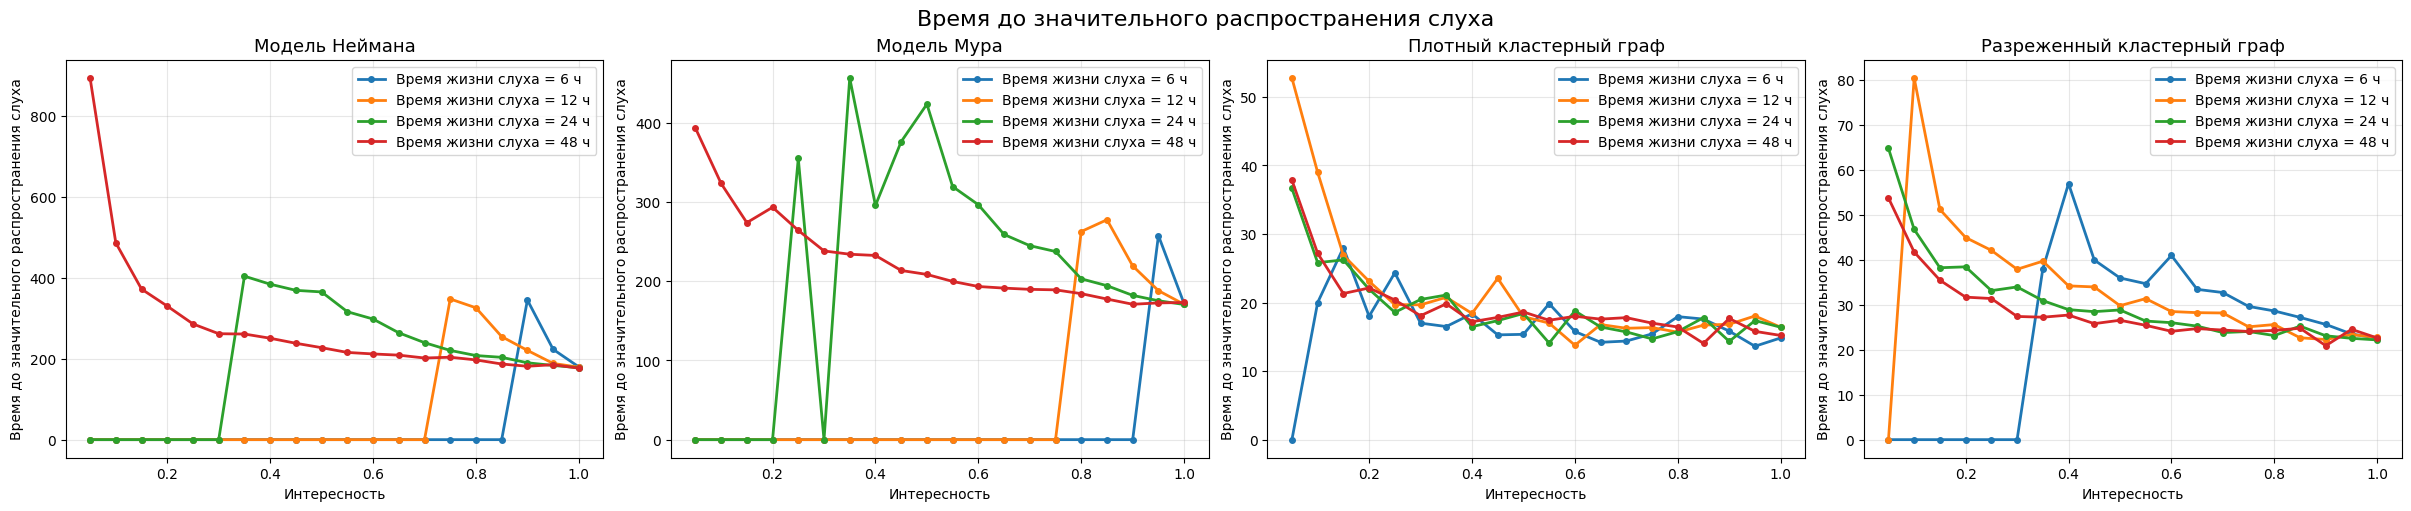

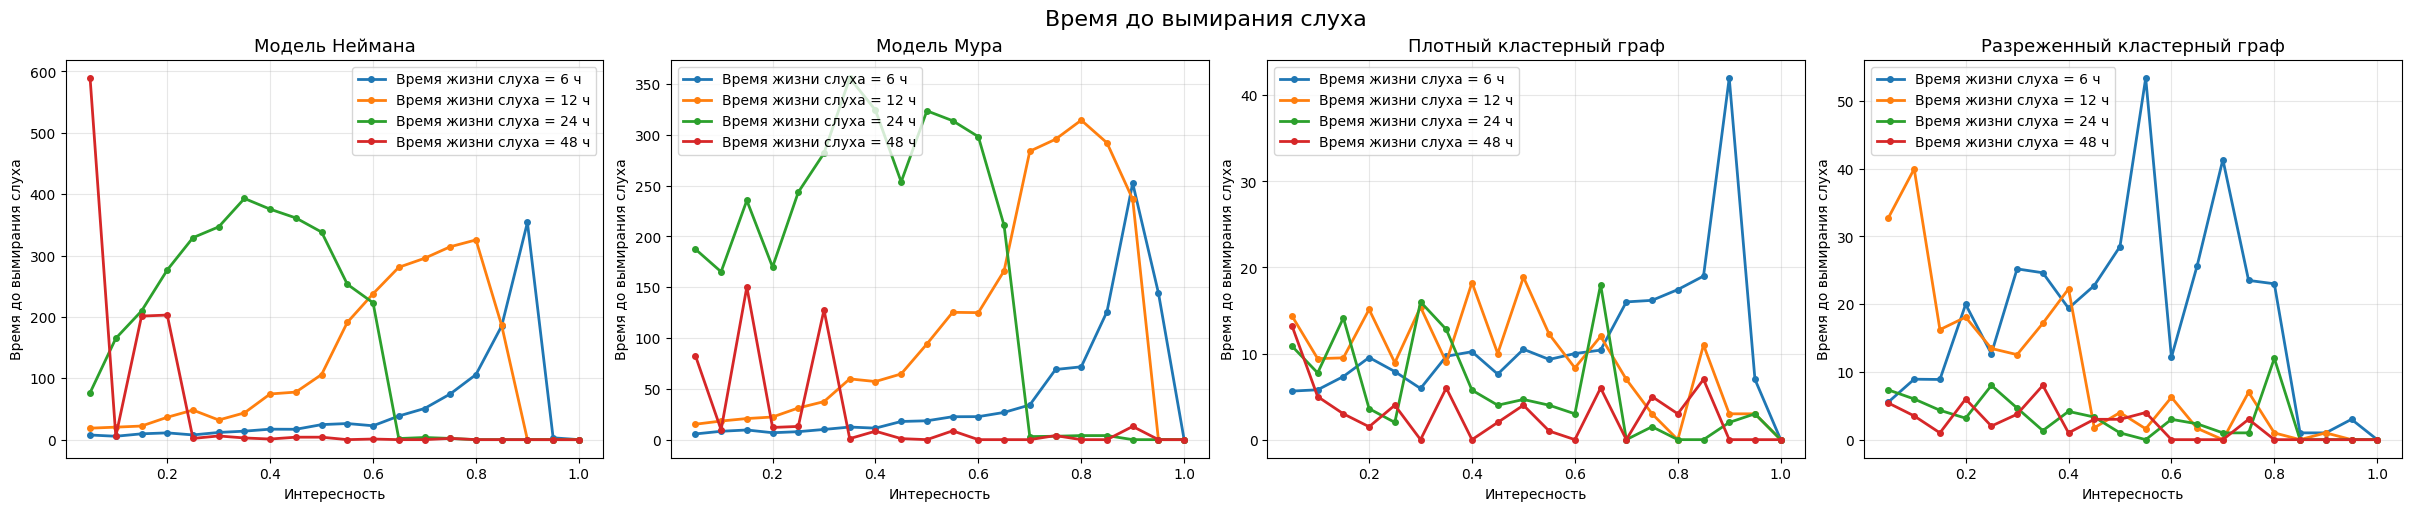

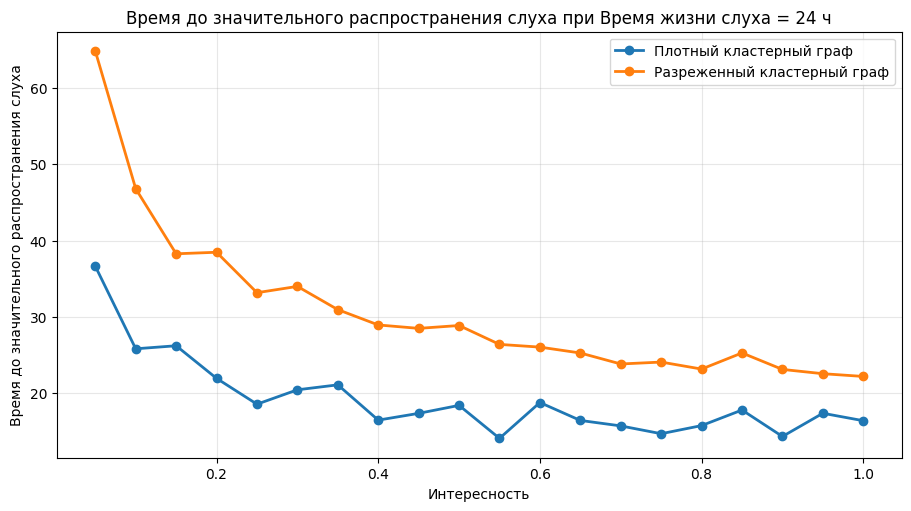

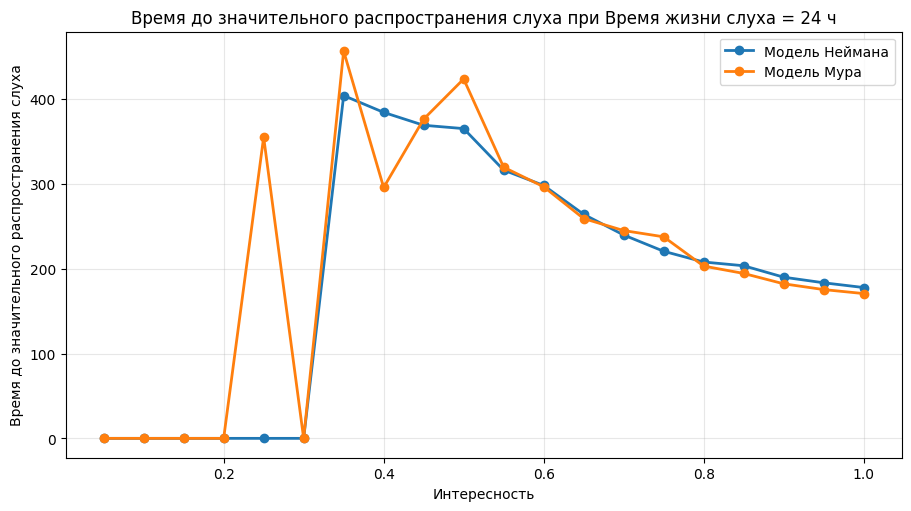

In [18]:
TOPONYM = {
    "grid4_beta_multiT": "Модель Неймана",
    "grid8_beta_multiT": "Модель Мура",
    "dense_graph_beta_multiT": "Плотный кластерный граф",
    "sparse_graph_beta_multiT": "Разреженный кластерный граф",
}

METRIC_NAME = {
    "success_rate": "Вероятность значительного распространения слуха",
    "good_mean_time": "Время до значительного распространения слуха",
    "bad_mean_time": "Время до вымирания слуха",
}

X_NAME = {
    "beta": "Интересность",
    "T": "Время жизни слуха",
}

def plot_metric_row(results_keys, metric_key, metric_title, ylabel):
    nplots = len(results_keys)
    fig, axes = plt.subplots(1, nplots, figsize=(6 * nplots, 5), constrained_layout=True)

    if nplots == 1:
        axes = [axes]

    for ax, key in zip(axes, results_keys):
        data = all_results[key]
        betas = data["betas"]
        Ts = data["Ts"]

        for T in Ts:
            vals = data["results"][T][metric_key]
            ax.plot(
                betas,
                vals,
                marker="o",
                linewidth=2,
                markersize=4,
                label=f"{X_NAME['T']} = {T} ч"
            )

        ax.set_title(TOPONYM[key], fontsize=13)
        ax.set_xlabel(X_NAME["beta"])
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)
        ax.legend()

    fig.suptitle(metric_title, fontsize=16)
    plt.show()
    return fig


keys = [
    "grid4_beta_multiT",
    "grid8_beta_multiT",
    "dense_graph_beta_multiT",
    "sparse_graph_beta_multiT",
]

# 1) Вероятность значительного распространения слуха
plot_metric_row(
    results_keys=keys,
    metric_key="success_rate",
    metric_title=METRIC_NAME["success_rate"],
    ylabel=METRIC_NAME["success_rate"]
)

# 2) Время до значительного распространения слуха
plot_metric_row(
    results_keys=keys,
    metric_key="good_mean_time",
    metric_title=METRIC_NAME["good_mean_time"],
    ylabel=METRIC_NAME["good_mean_time"]
)

# 3) Время до вымирания слуха
plot_metric_row(
    results_keys=keys,
    metric_key="bad_mean_time",
    metric_title=METRIC_NAME["bad_mean_time"],
    ylabel=METRIC_NAME["bad_mean_time"]
)

# 4) Сравнение плотного и разреженного кластерного графа для T = 24
central_T = 24

fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)

ax.plot(
    all_results["dense_graph_beta_multiT"]["betas"],
    all_results["dense_graph_beta_multiT"]["results"][central_T]["good_mean_time"],
    marker="o",
    linewidth=2,
    label=TOPONYM["dense_graph_beta_multiT"]
)

ax.plot(
    all_results["sparse_graph_beta_multiT"]["betas"],
    all_results["sparse_graph_beta_multiT"]["results"][central_T]["good_mean_time"],
    marker="o",
    linewidth=2,
    label=TOPONYM["sparse_graph_beta_multiT"]
)

ax.set_title(f"{METRIC_NAME['good_mean_time']} при {X_NAME['T']} = {central_T} ч")
ax.set_xlabel(X_NAME["beta"])
ax.set_ylabel(METRIC_NAME["good_mean_time"])
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()
central_T = 24

fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)

ax.plot(
    all_results["grid4_beta_multiT"]["betas"],
    all_results["grid4_beta_multiT"]["results"][central_T]["good_mean_time"],
    marker="o",
    linewidth=2,
    label=TOPONYM["grid4_beta_multiT"]
)

ax.plot(
    all_results["grid8_beta_multiT"]["betas"],
    all_results["grid8_beta_multiT"]["results"][central_T]["good_mean_time"],
    marker="o",
    linewidth=2,
    label=TOPONYM["grid8_beta_multiT"]
)

ax.set_title(f"{METRIC_NAME['good_mean_time']} при {X_NAME['T']} = {central_T} ч")
ax.set_xlabel(X_NAME["beta"])
ax.set_ylabel(METRIC_NAME["good_mean_time"])
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()